In [40]:
#If there is a trained .h5 model, remove the "#" in the code line
# Load model

#Below is the code for loading model remove # in next 3 lines to load the model
#from tensorflow.keras.models import load_model

#model = load_model("activity_model.h5")
#print("Model loaded successfully")

#if there is no any trained models, proceed with running the below cells

In [27]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Bidirectional, Conv1D, BatchNormalization
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.utils import class_weight
from tqdm import tqdm

# Enable mixed precision for performance boost
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

# Parameters
IMG_SIZE = 160
FRAMES_PER_VIDEO = 30
DATASET_PATH = "Human Activity Recognition - Video Dataset"

# Step 1: Extract frames and EfficientNetB0 features
def extract_features(video_path):
    frames = []
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_interval = max(1, total_frames // FRAMES_PER_VIDEO)
    count = 0

    while len(frames) < FRAMES_PER_VIDEO and cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if count % frame_interval == 0:
            frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
            frame = img_to_array(frame)
            frame = preprocess_input(frame)
            frames.append(frame)
        count += 1

    cap.release()
    while len(frames) < FRAMES_PER_VIDEO:
        frames.append(np.zeros((IMG_SIZE, IMG_SIZE, 3)))

    frames = np.array(frames)
    features = feature_extractor.predict(frames, verbose=0)
    return features

# Load EfficientNetB0 as feature extractor
feature_extractor = EfficientNetB0(include_top=False, weights='imagenet', pooling='avg', input_shape=(IMG_SIZE, IMG_SIZE, 3))
feature_extractor.trainable = False

# Step 2: Prepare dataset
X, y = [], []
labels = os.listdir(DATASET_PATH)
print("Extracting features... (once only)")

for label in tqdm(labels):
    class_folder = os.path.join(DATASET_PATH, label)
    for video_file in os.listdir(class_folder):
        if video_file.endswith((".mp4", ".avi")):
            path = os.path.join(class_folder, video_file)
            try:
                features = extract_features(path)
                X.append(features)
                y.append(label)
            except:
                continue

X = np.array(X)
y = np.array(y)

# Encode labels
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
y_cat = to_categorical(y_encoded)

# Compute class weights
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_encoded), y=y_encoded)
class_weight_dict = dict(enumerate(class_weights))

# Train-test split
X_train, X_val, y_train, y_val = train_test_split(X, y_cat, test_size=0.2, stratify=y_cat, random_state=42)

# Step 3: Define regularized LSTM model
model = Sequential([
    Conv1D(64, 3, activation='relu', input_shape=(FRAMES_PER_VIDEO, 1280)),
    BatchNormalization(),
    Dropout(0.3),
    Conv1D(64, 3, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Bidirectional(LSTM(128, return_sequences=False)),
    Dropout(0.6),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(len(labels), activation='softmax', dtype='float32')
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

# Step 4: Train with callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=12,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

# Step 5: Evaluation
val_loss, val_acc = model.evaluate(X_val, y_val)
print(f"Validation Accuracy: {val_acc * 100:.2f}%")


Extracting features... (once only)


100%|██████████| 7/7 [22:07<00:00, 189.63s/it]
/Users/yagnesh/Library/Python/3.9/lib/python/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.2910 - loss: 1.7998 - val_accuracy: 0.6368 - val_loss: 1.0697 - learning_rate: 0.0010
Epoch 2/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7338 - loss: 0.8929 - val_accuracy: 0.8520 - val_loss: 0.6351 - learning_rate: 0.0010
Epoch 3/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8185 - loss: 0.7297 - val_accuracy: 0.9013 - val_loss: 0.5399 - learning_rate: 0.0010
Epoch 4/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8931 - loss: 0.5952 - val_accuracy: 0.9283 - val_loss: 0.4812 - learning_rate: 0.0010
Epoch 5/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9459 - loss: 0.4684 - val_accuracy: 0.9686 - val_loss: 0.3557 - learning_rate: 0.0010
Epoch 6/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9515 - loss: 0.4639 - val_accuracy: 0.9686 - val_loss: 0.3370 - learning_rate: 0.0010
Epoch 7/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9344 - loss: 0.4931 - val_acc

In [66]:
print(f"Validation Loss: {val_loss}")

Validation Loss: 0.3369583785533905


In [48]:
# Save the Model

model.save("activity_model.h5")
print("Model saved as activity_model.h5")


Model saved as activity_model.h5


In [47]:
# Classification Report

from sklearn.metrics import classification_report

# True & predicted classes
y_true = np.argmax(y_val, axis=1)
y_pred_classes = np.argmax(y_pred, axis=1)

# Print metrics
report = classification_report(y_true, y_pred_classes, target_names=encoder.classes_, digits=4)
print("Classification Report:\n")
print(report)


Classification Report:

                            precision    recall  f1-score   support

                  Clapping     1.0000    1.0000    1.0000        29
            Meet and Split     0.9375    1.0000    0.9677        30
                   Sitting     1.0000    1.0000    1.0000        31
            Standing Still     1.0000    1.0000    1.0000        35
                   Walking     0.8857    0.9118    0.8986        34
Walking While Reading Book     1.0000    0.9429    0.9706        35
 Walking While Using Phone     0.9643    0.9310    0.9474        29

                  accuracy                         0.9686       223
                 macro avg     0.9696    0.9694    0.9692       223
              weighted avg     0.9695    0.9686    0.9687       223



In [49]:
#Macro & Weighted Averages Separately

from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_true, y_pred_classes, average='macro')
recall = recall_score(y_true, y_pred_classes, average='macro')
f1 = f1_score(y_true, y_pred_classes, average='macro')

print(f"Macro-Averaged Precision: {precision:.4f}")
print(f"Macro-Averaged Recall   : {recall:.4f}")
print(f"Macro-Averaged F1-score : {f1:.4f}")


Macro-Averaged Precision: 0.9696
Macro-Averaged Recall   : 0.9694
Macro-Averaged F1-score : 0.9692


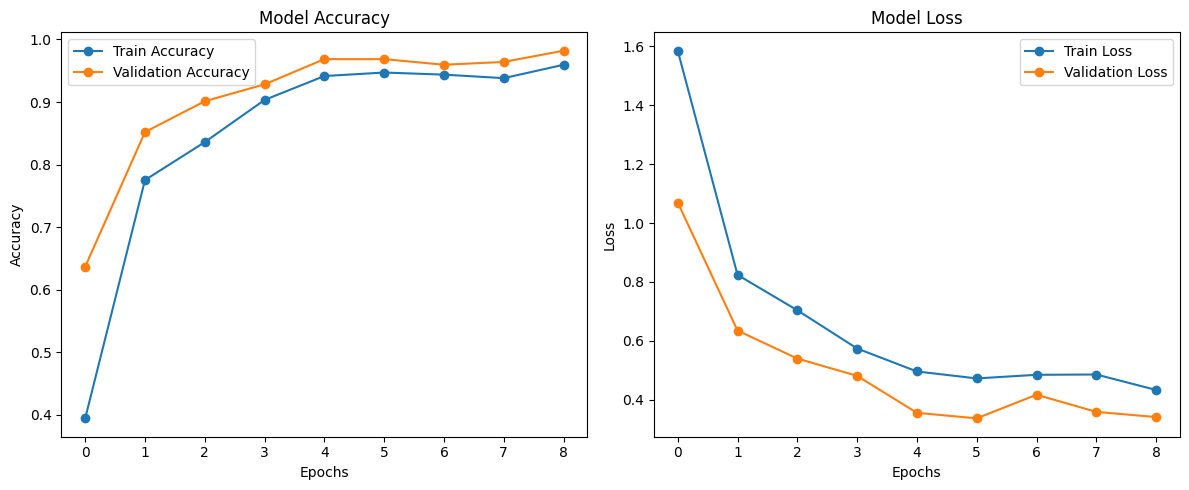

In [50]:
#Visualisations

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


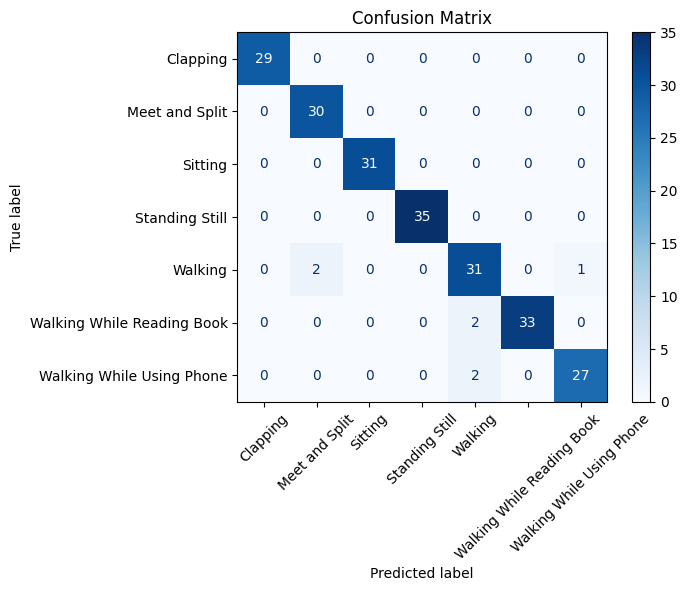

In [51]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Predictions
y_pred = model.predict(X_val)
y_true = np.argmax(y_val, axis=1)
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()


In [54]:
# Class-wise Accuracy

class_accuracies = cm.diagonal() / cm.sum(axis=1)
for i, acc in enumerate(class_accuracies):
    print(f"{encoder.classes_[i]} Accuracy: {acc:.2%}")


Clapping Accuracy: 100.00%
Meet and Split Accuracy: 100.00%
Sitting Accuracy: 100.00%
Standing Still Accuracy: 100.00%
Walking Accuracy: 91.18%
Walking While Reading Book Accuracy: 94.29%
Walking While Using Phone Accuracy: 93.10%


In [52]:
# Sample Predictions with Probabilities

import random

sample_indices = random.sample(range(len(X_val)), 5)
for idx in sample_indices:
    probs = y_pred[idx]
    top_class = encoder.classes_[np.argmax(probs)]
    confidence = np.max(probs)
    true_class = encoder.classes_[np.argmax(y_val[idx])]
    print(f"True: {true_class} | Predicted: {top_class} ({confidence:.2%})")


True: Walking While Reading Book | Predicted: Walking While Reading Book (99.56%)
True: Walking While Reading Book | Predicted: Walking While Reading Book (98.72%)
True: Walking | Predicted: Meet and Split (88.33%)
True: Clapping | Predicted: Clapping (99.18%)
True: Walking | Predicted: Walking (98.17%)


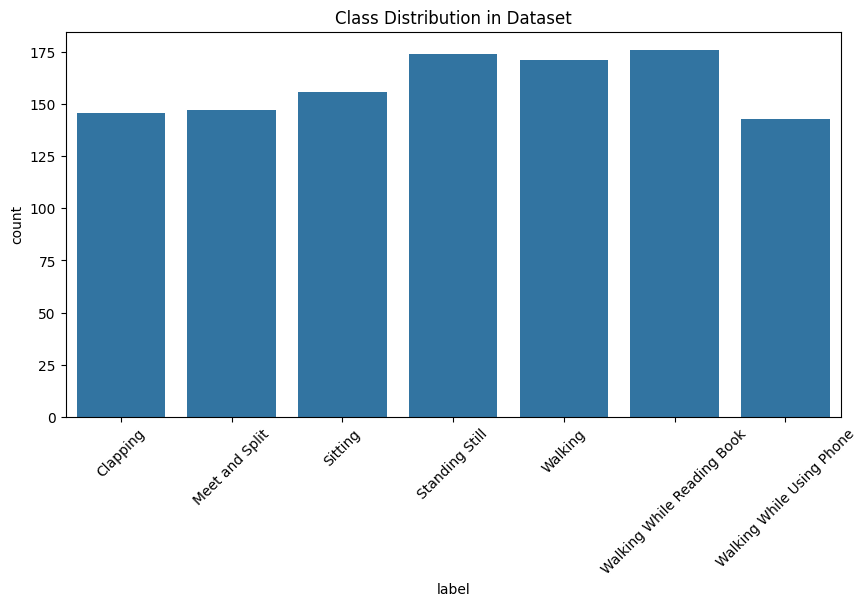

In [53]:
# Class Distribution in Dataset

import seaborn as sns
import pandas as pd

df = pd.DataFrame({'label': y})
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='label', order=encoder.classes_)
plt.title("Class Distribution in Dataset")
plt.xticks(rotation=45)
plt.show()


In [55]:
# Custom Video Prediction

def predict_activity_on_video(video_path, model, extractor, encoder, frame_count=30, img_size=160):
    cap = cv2.VideoCapture(video_path)
    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_interval = max(1, total_frames // frame_count)
    count = 0

    while len(frames) < frame_count and cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if count % frame_interval == 0:
            frame = cv2.resize(frame, (img_size, img_size))
            frame = img_to_array(frame)
            frame = preprocess_input(frame)
            frames.append(frame)
        count += 1
    cap.release()

    while len(frames) < frame_count:
        frames.append(np.zeros((img_size, img_size, 3)))

    input_frames = np.array(frames)
    features = extractor.predict(input_frames, verbose=0)
    features = np.expand_dims(features, axis=0)  # (1, frames, features)

    prediction = model.predict(features)
    predicted_index = np.argmax(prediction)
    predicted_label = encoder.classes_[predicted_index]
    confidence = np.max(prediction)

    print(f"Prediction: {predicted_label} ({confidence:.2%} confidence)")
    return predicted_label, confidence


In [56]:
custom_video_path = "Human Activity Recognition - Video Dataset/Standing Still/Standing Still (2).mp4"  # path for test video file
predict_activity_on_video(custom_video_path, model, feature_extractor, encoder)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Prediction: Standing Still (96.36% confidence)


(np.str_('Standing Still'), np.float32(0.96362966))